# TQ_James_OShaughnessy_Value：基石價值策略（Cornerstone Value）

> **策略類型：** 基本面多因子篩選 — 截面價值排名  
> **交易標的：** 台股上市/上櫃普通股（排除金融業）  
> **調倉頻率：** 年度再平衡  
> **策略來源：** James O'Shaughnessy《What Works on Wall Street》— Cornerstone Value Strategy

---

## 📌 策略概述

O'Shaughnessy 基石價值策略的核心邏輯，是在**大型收益股**中尋找同時滿足現金流充裕、估值偏低、高殖利率三項條件的標的。

### 選股六道篩選條件

| 條件 | 說明 |
|:---|:---|
| 1. 大型股 | 市值 > 當期市場平均市值 |
| 2. 正現金流 | 每股營業現金流 > 0 |
| 3. 現金流估值偏低 | P/CF < 當期市場平均 P/CF |
| 4. 流通股數正常 | 普通股股數 > 0（排除異常） |
| 5. 高收益企業 | 每股營收 > 當期市場平均的 2.5 倍 |
| 6. 銷售估值偏低 | PSR < 當期市場平均 PSR |

通過六道篩選後，按**現金殖利率由高至低**選出前 30 檔持倉。

## 📌 Cell 1：環境設定 & 套件載入

In [1]:
%matplotlib inline
import os
import gc
import pandas as pd
import numpy as np
import tejapi
import matplotlib
import matplotlib.pyplot as plt
from logbook import Logger

# ── TEJ API ──────────────────────────────────────────────────────────────────
os.environ['TEJAPI_KEY']  = '請輸入API'
os.environ['TEJAPI_BASE'] = 'https://api.tej.com.tw'
tejapi.ApiConfig.api_key  = os.getenv('TEJAPI_KEY')
tejapi.ApiConfig.api_base = os.getenv('TEJAPI_BASE')

# ── Zipline / TejToolAPI ──────────────────────────────────────────────────────
from zipline.sources.TEJ_Api_Data import get_universe
import TejToolAPI
from zipline.data.run_ingest import simple_ingest
from zipline.api import (
    set_slippage, set_commission, set_benchmark,
    symbol, record, order_target_percent,
    schedule_function, date_rules, time_rules
)
from zipline.finance import commission, slippage
from zipline import run_algorithm

log = Logger('OSV')

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK TC']
plt.rcParams['axes.unicode_minus'] = False
print('環境設定完成')

環境設定完成


## 📌 Cell 2：參數設定

In [2]:
# ── 回測區間 ─────────────────────────────────────────────────────────────────
DATA_START      = '2019-01-01'   # 基本面資料起始（需早於回測，確保首次選股有資料）
BACKTEST_START  = '2022-07-01'   # 回測正式開始日
BACKTEST_END    = '2025-06-01'   # 回測結束日
CAPITAL_BASE    = 1_000_000      # 初始資金（元）

# ── 選股條件 ──────────────────────────────────────────────────────────────────
SALES_MULTIPLE  = 2.5   # 每股營收須超過市場平均的倍數
TOP_N           = 30    # 最終持倉檔數（依殖利率排序取前 N）

# ── 再平衡設定 ────────────────────────────────────────────────────────────────
REBAL_MONTH     = 7     # 每年幾月做再平衡（7 = 七月，配合回測起始月）

# ── 資料欄位對照（TejToolAPI 英文欄位名稱）──────────────────────────────────────
COLUMNS = [
    'coid',
    'mktcap',        # 市值                   → Market_Cap_Dollars
    'susp_fg',       # 停牌旗標               → Suspended_Trading_Stock_Fg
    'a2111',         # 普通股股數             → Common_Stock_Shares_Q
    'psr_tej',       # 股價營收比_TEJ         → PSR_TEJ
    'a7210',         # 來自營運之現金流量     → Net_Cash_Flows_From_Used_In_Operating_Activities_Q
    'r304',          # 每股營業額             → Sales_Per_Share_Q
    'shares',        # 流通在外股數_千股      → Issue_Shares_1000_Shares
    'div_yid',       # 股利殖利率             → Dividend_Yield_TWSE
]

print(f'回測期間：{BACKTEST_START} ~ {BACKTEST_END}')
print(f'選股邏輯：六道條件過濾 → 殖利率前 {TOP_N} 名')
print(f'再平衡月份：每年 {REBAL_MONTH} 月初')

回測期間：2022-07-01 ~ 2025-06-01
選股邏輯：六道條件過濾 → 殖利率前 30 名
再平衡月份：每年 7 月初


## 📌 Cell 3：投資宇宙建立 & 基本面資料拉取

- 母體：上市/上櫃普通股，排除金融業（M9700、OTC97）
- 資料頻率：季頻（`fin_type='Q'`），透過 TejToolAPI 自動對齊至交易日

In [3]:
# ── 投資母體 ──────────────────────────────────────────────────────────────────
_universe_kwargs = dict(
    start      = DATA_START,
    end        = BACKTEST_END,
    mkt_bd_e   = ['TSE', 'OTC'],
    stktp_e    = ['Common Stock', 'Common Stock-Foreign'],
    main_ind_e = 'General Industry',
)

pool_all  = get_universe(**_universe_kwargs)
pool_fin  = get_universe(**{**_universe_kwargs, 'main_ind_e': ['M9700', 'OTC97']})
pool      = sorted(set(pool_all) - set(pool_fin))

print(f'全市場母體：{len(pool_all)} 支')
print(f'排除金融業後：{len(pool)} 支')

del pool_all, pool_fin
gc.collect()

# ── 拉取基本面資料 ──────────────────────────────────────────────────────────────
start_dt = pd.Timestamp(DATA_START,    tz='UTC')
end_dt   = pd.Timestamp(BACKTEST_END,  tz='UTC')

data_use = TejToolAPI.get_history_data(
    start              = start_dt,
    end                = end_dt,
    ticker             = pool,
    fin_type           = 'Q',
    columns            = COLUMNS,
    transfer_to_chinese = False,
)

# 記憶體優化
data_use['coid']                       = data_use['coid'].astype('category')
data_use['Suspended_Trading_Stock_Fg'] = data_use['Suspended_Trading_Stock_Fg'].astype('category')
for col in data_use.select_dtypes('float64').columns:
    data_use[col] = data_use[col].astype('float32')

print(f'資料筆數：{len(data_use):,}，欄位：{list(data_use.columns)}')
gc.collect()

Currently used TEJ API key call quota 1684/100000 (1.68%)
Currently used TEJ API key data quota 114157615/10000000 (1141.58%)
Currently used TEJ API key call quota 1685/100000 (1.69%)
Currently used TEJ API key data quota 114157615/10000000 (1141.58%)
全市場母體：1909 支
排除金融業後：1909 支
Currently used TEJ API key call quota 1963/100000 (1.96%)
Currently used TEJ API key data quota 128617415/10000000 (1286.17%)
資料筆數：2,671,202，欄位：['coid', 'mdate', 'Issue_Shares_1000_Shares', 'Dividend_Yield_TWSE', 'Market_Cap_Dollars', 'Sales_Per_Share_Q', 'PSR_TEJ', 'Common_Stock_Shares_Q', 'Suspended_Trading_Stock_Fg', 'Net_Cash_Flows_From_Used_In_Operating_Activities_Q']


0

## 📌 Cell 4：資料清洗 & 特徵工程

1. 排除停牌股
2. 計算每股營業現金流（Cash_Per_Share）、P/CF 比率
3. 計算每個截面日的市場平均值（供後續條件比較用）

In [4]:
# ── 資料清洗 ──────────────────────────────────────────────────────────────────
data_use = data_use.sort_values(['coid', 'mdate'])

# 排除停牌
data_use = data_use[data_use['Suspended_Trading_Stock_Fg'].str.strip() != 'Y']

# 選取必要欄位
necessary_cols = [
    'coid', 'mdate',
    'Market_Cap_Dollars',
    'Common_Stock_Shares_Q',
    'PSR_TEJ',
    'Sales_Per_Share_Q',
    'Net_Cash_Flows_From_Used_In_Operating_Activities_Q',
    'Issue_Shares_1000_Shares',
    'Dividend_Yield_TWSE',
]
data_use = data_use[[c for c in necessary_cols if c in data_use.columns]].copy()

# 排除現金流為零或股數為零的列（避免除零）
data_use = data_use[
    (data_use['Net_Cash_Flows_From_Used_In_Operating_Activities_Q'] != 0) &
    (data_use['Issue_Shares_1000_Shares'] > 0)
].copy()

gc.collect()

# ── 特徵工程 ───────────────────────────────────────────────────────────────────
# 每股營業現金流
data_use['Cash_Per_Share'] = (
    data_use['Net_Cash_Flows_From_Used_In_Operating_Activities_Q'] /
    data_use['Issue_Shares_1000_Shares']
)

# P/CF 比率（市值 / 季度營業現金流）
data_use['Price_to_Cash_Flow_Ratio'] = (
    data_use['Market_Cap_Dollars'] /
    data_use['Net_Cash_Flows_From_Used_In_Operating_Activities_Q']
)

# 截面平均值（依日期）
grouped = data_use.groupby('mdate', observed=True)

# 正現金流子集的平均 P/CF（排除負值避免失真）
pos_cf_avg = (
    data_use[data_use['Net_Cash_Flows_From_Used_In_Operating_Activities_Q'] > 0]
    .groupby('mdate', observed=True)['Price_to_Cash_Flow_Ratio']
    .mean()
)

data_use['Ave_Market_Cap']         = data_use['mdate'].map(grouped['Market_Cap_Dollars'].mean())
data_use['Ave_Common_Stocks']      = data_use['mdate'].map(grouped['Common_Stock_Shares_Q'].mean())
data_use['Ave_PSR']                = data_use['mdate'].map(grouped['PSR_TEJ'].mean())
data_use['Ave_Sales_Per_Share']    = data_use['mdate'].map(grouped['Sales_Per_Share_Q'].mean())
data_use['Ave_PCF_Ratio']         = data_use['mdate'].map(pos_cf_avg)

data_use = data_use.sort_values(['coid', 'mdate']).reset_index(drop=True)

# 建立日期索引加速查找
_date_index = {d: df for d, df in data_use.groupby('mdate', observed=True)}

del grouped, pos_cf_avg
gc.collect()

print(f'特徵工程完成，有效資料筆數：{len(data_use):,}')
print(f'可用截面日數：{len(_date_index)}')

特徵工程完成，有效資料筆數：2,665,738
可用截面日數：1553


## 📌 Cell 5：資料匯入（simple_ingest）

將母體股票與基準指數 IR0001 匯入 tquant bundle，供 Zipline 回測引擎使用。

In [5]:
simple_ingest(
    name       = 'tquant',
    tickers    = pool + ['IR0001'],
    start_date = BACKTEST_START,
    end_date   = BACKTEST_END,
)
gc.collect()
print('simple_ingest 完成')

Now ingesting data.


[2026-04-01 03:27:56.539748] INFO: zipline.data.bundles.core: Ingesting tquant.


Merging daily equity files:


[2026-04-01 03:30:34.145643] INFO: zipline.data.bundles.core: Ingest tquant successfully.


Currently used TEJ API key call quota 1969/100000 (1.97%)
Currently used TEJ API key data quota 131123856/10000000 (1311.24%)
End of ingesting tquant.
Please call function `get_bundle(start_dt = pd.Timestamp('2022-07-01', tz = 'utc'),end_dt = pd.Timestamp('2025-06-01' ,tz = 'utc'))` in `zipline.data.data_portal` to check data.
Currently used TEJ API key call quota 1969/100000 (1.97%)
Currently used TEJ API key data quota 131123856/10000000 (1311.24%)
simple_ingest 完成


## 📌 Cell 6：選股函式（compute_stock）

依據回測當日，從已對齊的基本面資料中取最近一期截面，套用六道條件後依殖利率排序。

> **修正說明**：原始版本使用精確日期比對，若季報資料無當日記錄則會回傳空集合。  
> 現改為「取 ≤ 當日的最近有效截面日」，確保每次選股都能取到最新一期資料。

In [6]:
def compute_stock(date: str) -> list:
    """
    O'Shaughnessy Cornerstone Value 選股邏輯

    六道條件：
        1. 市值 > 市場平均市值          （大型股）
        2. 每股現金流 > 0               （正現金流）
        3. P/CF < 市場平均 P/CF         （現金流估值偏低）
        4. 普通股股本 > 0               （基本有效性）
        5. 每股營收 > 市場平均 × 2.5    （高收益企業）
        6. PSR < 市場平均 PSR           （銷售估值偏低）

    最終排序：依現金殖利率由高至低，取前 TOP_N 檔。
    """
    target = pd.Timestamp(date)

    # 取最近有效截面日（≤ 當日）
    available = sorted(_date_index.keys())
    valid = [d for d in available if pd.Timestamp(d) <= target]
    if not valid:
        log.warn(f'[{date}] 無可用基本面資料')
        return []
    df = _date_index[valid[-1]].copy()

    # ── 六道篩選 ──────────────────────────────────────────────────────────────
    mask = (
        (df['Market_Cap_Dollars']                    >  df['Ave_Market_Cap'])          &  # 1
        (df['Cash_Per_Share']                        >  0)                             &  # 2
        (df['Price_to_Cash_Flow_Ratio']              <  df['Ave_PCF_Ratio'])           &  # 3
        (df['Common_Stock_Shares_Q']                       >  0)                             &  # 4
        (df['Sales_Per_Share_Q']                     >  SALES_MULTIPLE * df['Ave_Sales_Per_Share'])  &  # 5
        (df['PSR_TEJ']                               <  df['Ave_PSR'])                 # 6
    )
    df = df[mask]

    if df.empty:
        log.warn(f'[{date}] 六道條件後無符合標的')
        return []

    # ── 依殖利率排序，取前 TOP_N ──────────────────────────────────────────────
    tickers = (
        df.sort_values('Dividend_Yield_TWSE', ascending=False)
        .head(TOP_N)['coid']
        .tolist()
    )

    log.info(f'[{date}] 截面日={valid[-1].date()}, 通過篩選={len(df)}, 最終持倉={len(tickers)}')
    return tickers


print('compute_stock 定義完成')

compute_stock 定義完成


## 📌 Cell 7：Zipline 回測函式

- **`initialize`**：設定交易成本、滑價、基準、排程年度換倉
- **`rebalance`**：每年指定月份執行一次，呼叫 `compute_stock` 並等權下單
- **`analyze`**：回測結束後繪製累計報酬、持倉檔數與槓桿走勢

In [7]:
_picks_log = {}   # {date_str: [ticker, ...]}，供事後分析用


def initialize(context):
    set_commission(commission.Custom_TW_Commission(
        min_trade_cost = 20,
        discount       = 1.0,
        tax            = 0.003,
    ))
    set_slippage(slippage.VolumeShareSlippage(
        volume_limit = 0.025,
        price_impact = 0.05,
    ))
    set_benchmark(symbol('IR0001'))

    # 年度再平衡：每年 REBAL_MONTH 月的第一個交易日執行
    schedule_function(
        rebalance,
        date_rules.month_start(days_offset=0),
        time_rules.market_open(),
    )

    context.current_holdings = []
    context.rebal_month      = REBAL_MONTH


def rebalance(context, data):
    today = data.current_dt
    if today.month != context.rebal_month:
        return

    new_tickers = compute_stock(str(today.date()))
    if not new_tickers:
        log.warn(f'[{today.date()}] 選股為空，跳過換倉')
        return

    _picks_log[str(today.date())] = new_tickers

    # 賣出不在新名單的持倉
    for ticker in context.current_holdings:
        if ticker not in new_tickers:
            order_target_percent(symbol(ticker), 0)

    # 買進新名單（等權重）
    weight = 1.0 / len(new_tickers)
    for ticker in new_tickers:
        order_target_percent(symbol(ticker), weight)

    context.current_holdings = new_tickers.copy()

    print(
        f'[換倉] {today.date()} | '
        f'持倉 {len(new_tickers)} 檔 | '
        f'單檔權重 {weight:.1%} | '
        f'槓桿 {context.account.leverage:.2f}'
    )

    record(
        n_positions = len(new_tickers),
        leverage    = context.account.leverage,
    )


def analyze(context, perf):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # 累計報酬
    axes[0].plot(perf.index, perf['algorithm_period_return'], label='Strategy', linewidth=1.5)
    axes[0].plot(perf.index, perf['benchmark_period_return'], label='Benchmark', linewidth=1.5, alpha=0.7)
    axes[0].set_title('Cumulative Returns', fontsize=12)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # 持倉檔數
    if 'n_positions' in perf.columns:
        axes[1].plot(perf.index, perf['n_positions'], color='steelblue')
        axes[1].set_title('Number of Positions', fontsize=12)
        axes[1].grid(alpha=0.3)

    # 槓桿
    if 'leverage' in perf.columns:
        axes[2].plot(perf.index, perf['leverage'], color='darkorange')
        axes[2].axhline(1.0, linestyle='--', color='gray', alpha=0.5)
        axes[2].set_title('Account Leverage', fontsize=12)
        axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('osv_strategy_performance.png', dpi=150, bbox_inches='tight')
    plt.show()


print('Zipline 函式定義完成')

Zipline 函式定義完成


## 📌 Cell 8：執行回測

O'Shaughnessy Cornerstone Value Strategy
  期間：2022-07-01 ~ 2025-06-01
  再平衡：每年 7 月初 | 持倉前 30 名（依殖利率）
[換倉] 2022-07-01 | 持倉 30 檔 | 單檔權重 3.3% | 槓桿 0.00
[換倉] 2023-07-03 | 持倉 30 檔 | 單檔權重 3.3% | 槓桿 0.96
[換倉] 2024-07-01 | 持倉 30 檔 | 單檔權重 3.3% | 槓桿 0.96


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK TC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK TC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK TC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK TC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK TC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK TC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK TC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK TC
findfont: Generic family 'sans-serif' not found because none of the foll

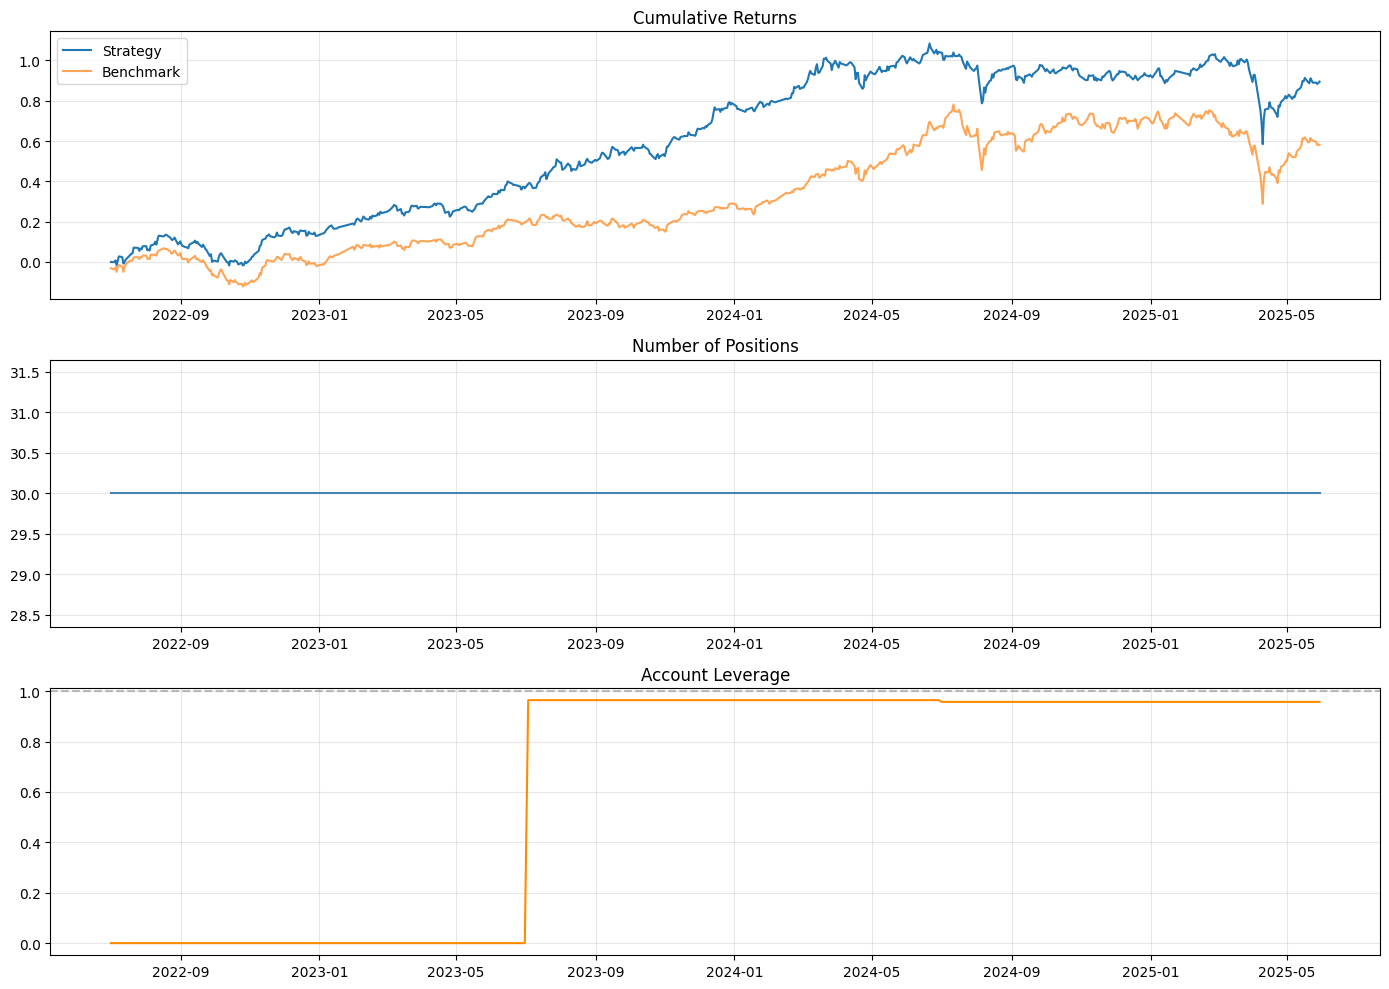


回測完成！


In [8]:
print('=' * 60)
print("O'Shaughnessy Cornerstone Value Strategy")
print(f'  期間：{BACKTEST_START} ~ {BACKTEST_END}')
print(f'  再平衡：每年 {REBAL_MONTH} 月初 | 持倉前 {TOP_N} 名（依殖利率）')
print('=' * 60)

results = run_algorithm(
    start                = pd.Timestamp(BACKTEST_START, tz='utc'),
    end                  = pd.Timestamp(BACKTEST_END,   tz='utc'),
    initialize           = initialize,
    handle_data          = None,
    analyze              = analyze,
    bundle               = 'tquant',
    capital_base         = CAPITAL_BASE,
    data_frequency       = 'daily',
)

print('\n回測完成！')

## 📌 Cell 9：績效統計 & Pyfolio 分析

------ 大盤績效 ------


Start date,2022-07-01
End date,2025-05-29
Total months,33
,Backtest
Annual return,17.799%
Cumulative returns,58.133%
Annual volatility,20.596%
Sharpe ratio,0.90
Calmar ratio,0.64
Stability,0.89
Max drawdown,-27.719%


Start date,2022-07-01
End date,2025-05-29
Total months,33
,Backtest
Annual return,25.673%
Cumulative returns,89.516%
Annual volatility,18.004%
Sharpe ratio,1.36
Calmar ratio,1.07
Stability,0.86
Max drawdown,-23.979%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,23.98,2024-06-20,2025-04-09,NaT,NaN
1,13.44,2022-08-18,2022-10-13,2022-11-17,64
2,7.67,2024-03-21,2024-04-22,2024-05-27,45
3,5.03,2023-04-14,2023-04-25,2023-05-24,28
4,4.53,2023-10-12,2023-10-23,2023-11-06,18


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

Top 10 long positions of all time,max
sid,
3017,8.20%
3036,6.68%
2385,5.97%
2404,5.37%
1477,5.28%
2382,5.24%
2356,5.14%
3044,5.07%
2603,4.99%


Top 10 short positions of all time,max
sid,


Top 10 positions of all time,max
sid,
3017,8.20%
3036,6.68%
2385,5.97%
2404,5.37%
1477,5.28%
2382,5.24%
2356,5.14%
3044,5.07%
2603,4.99%


findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

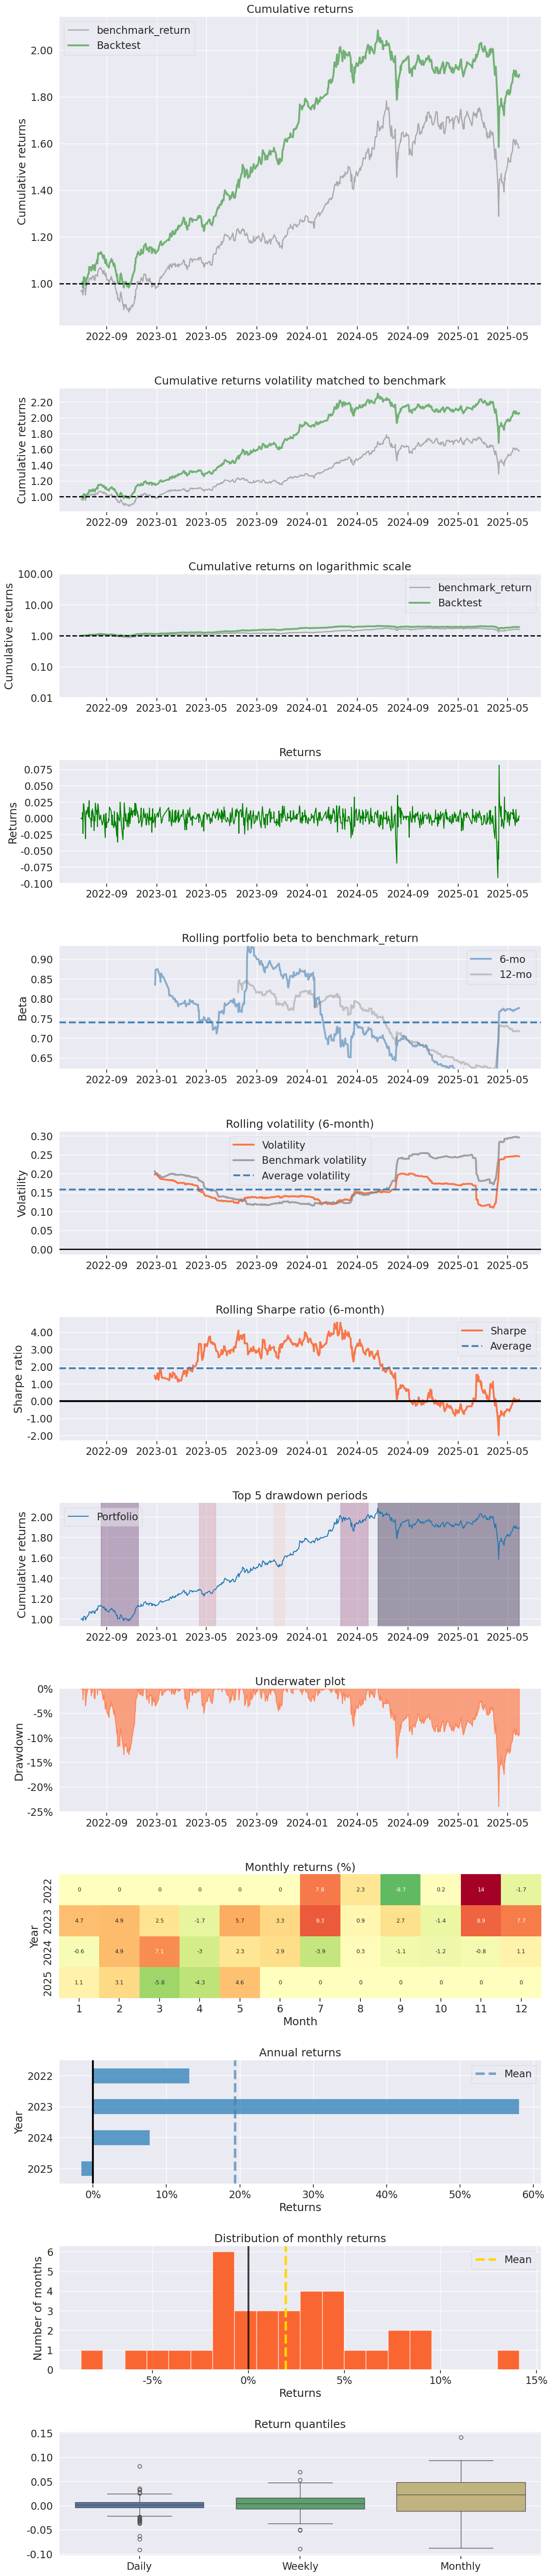

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

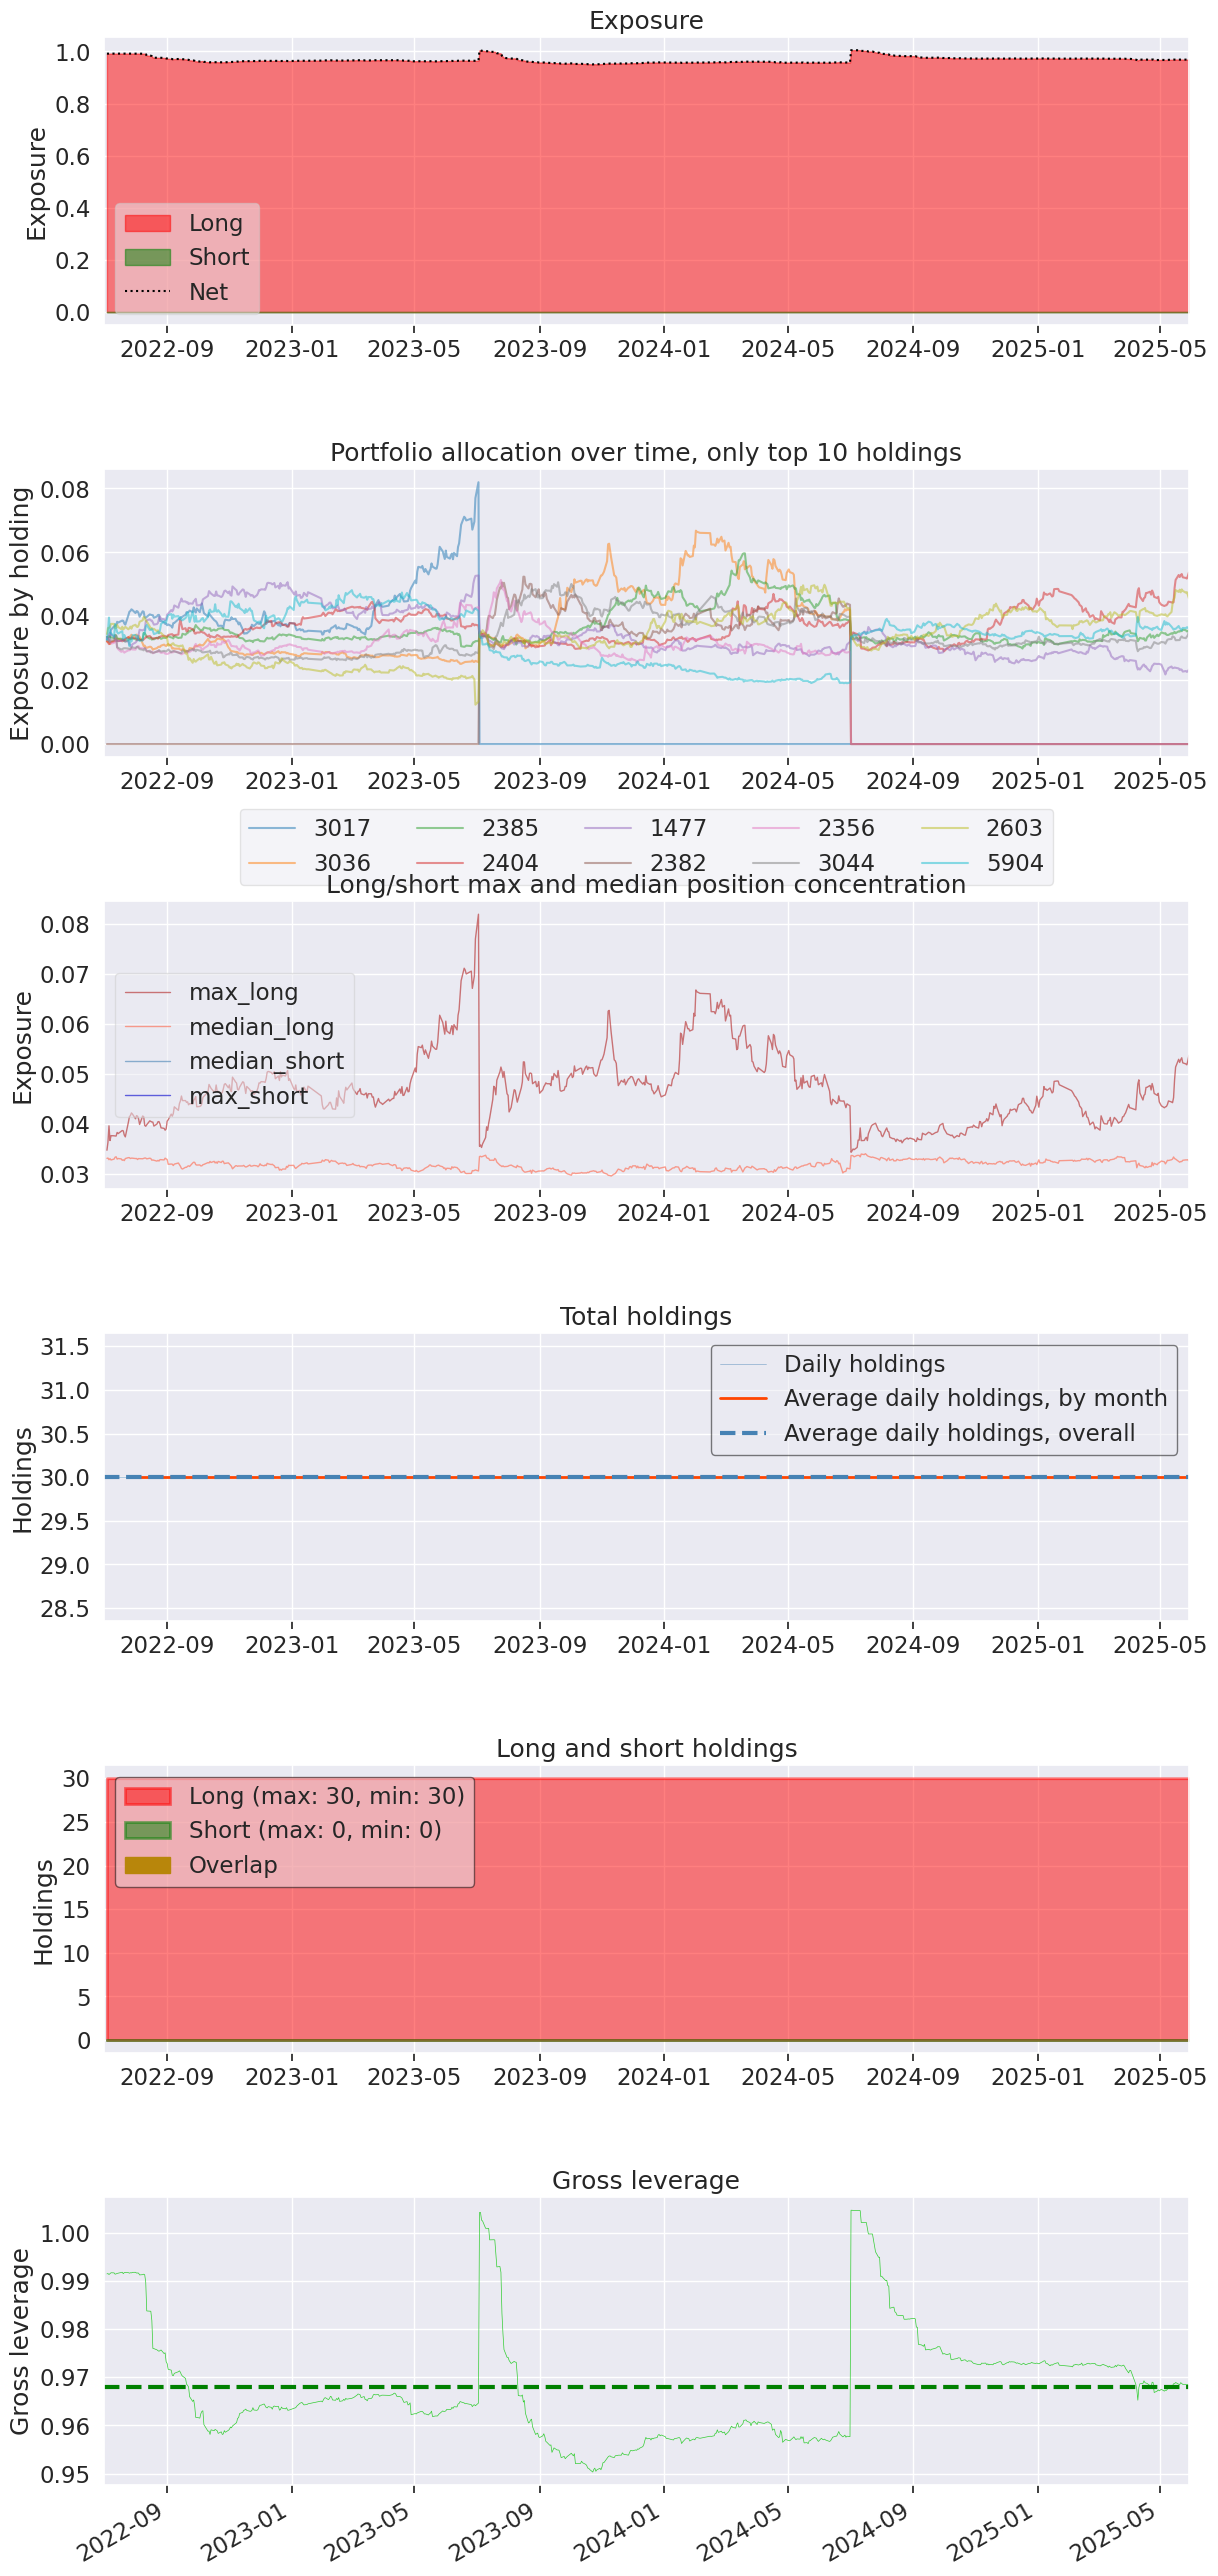

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

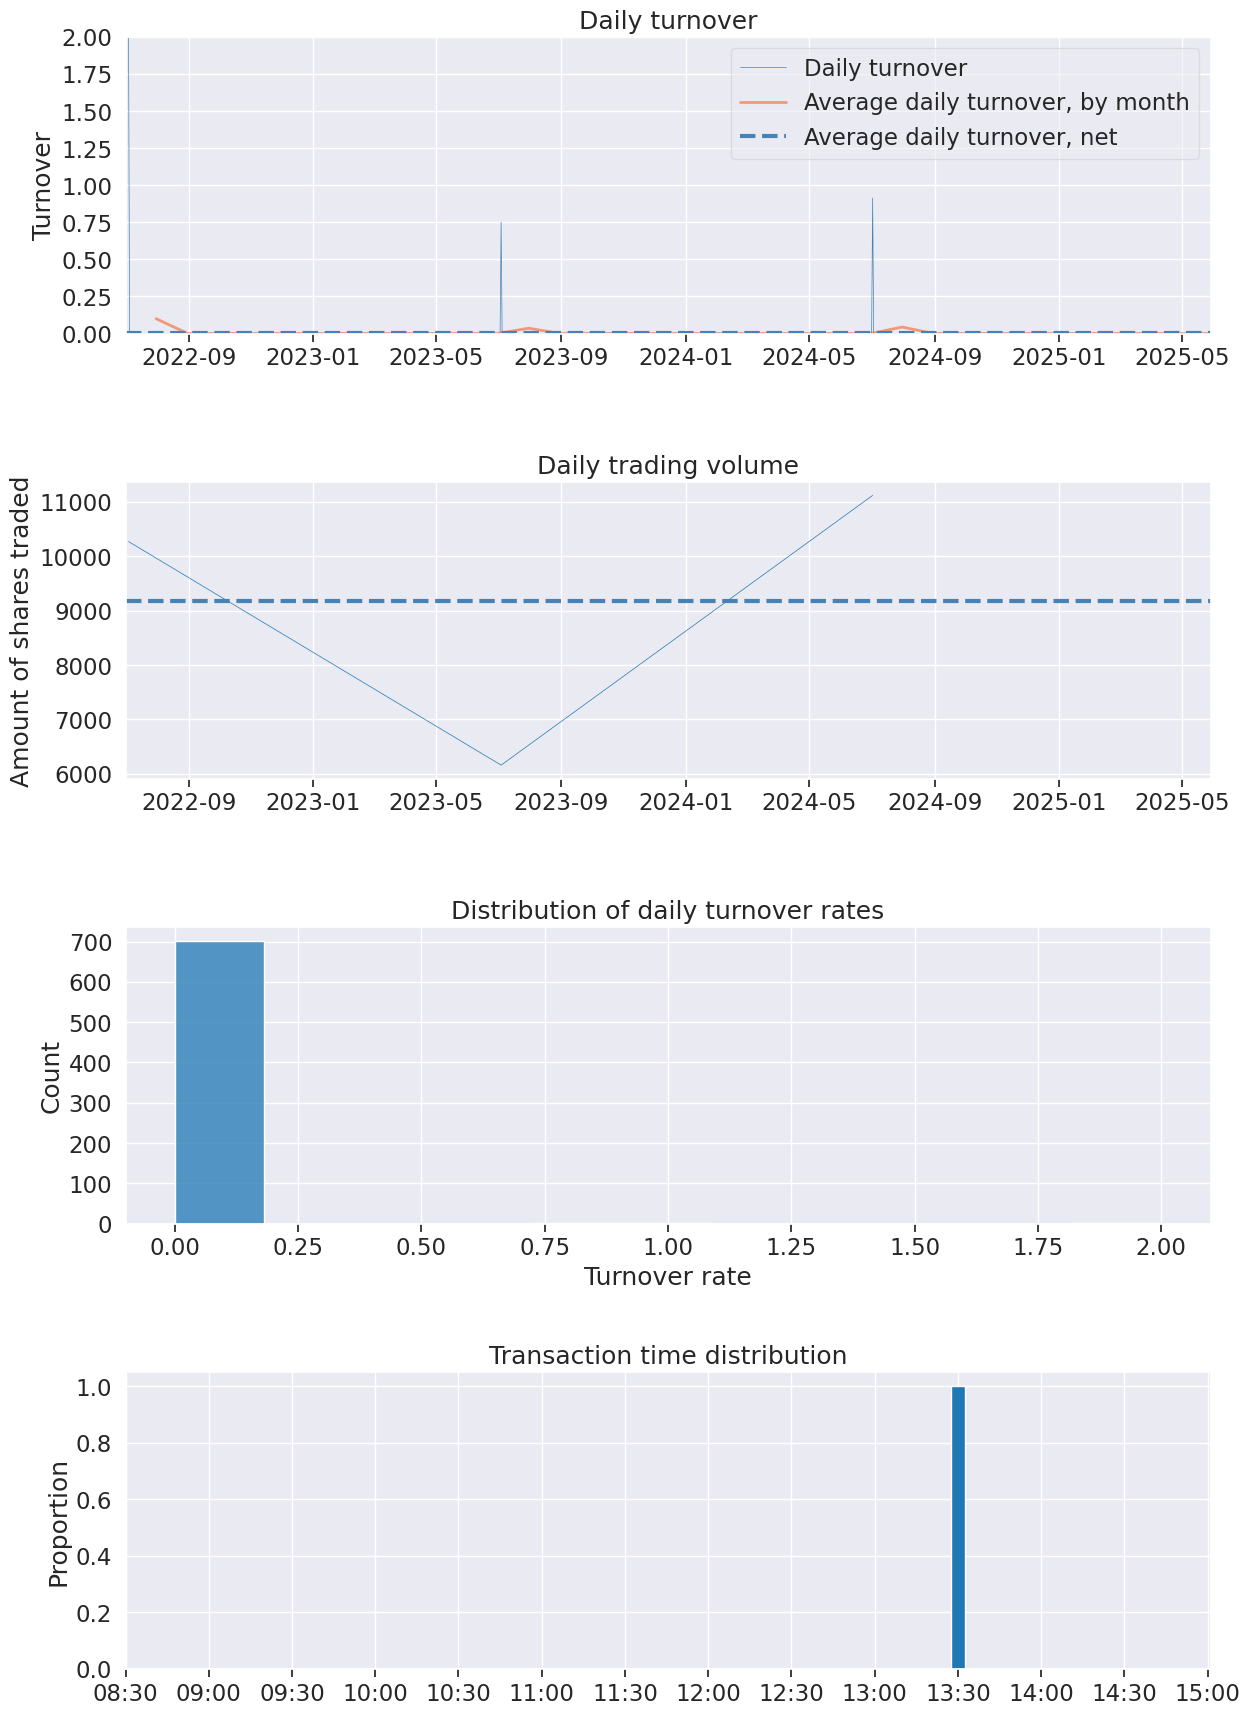

: 

In [ ]:
import pyfolio
from pyfolio.utils import extract_rets_pos_txn_from_zipline

returns, positions, transactions = extract_rets_pos_txn_from_zipline(results)
benchmark_rets = results['benchmark_return']

# ── Pyfolio ────────────────────────────────────────────────────────────────────
print('------ 大盤績效 ------')
pyfolio.show_perf_stats(benchmark_rets)
pyfolio.tears.create_full_tear_sheet(
    returns         = returns,
    positions       = positions,
    transactions    = transactions,
    benchmark_rets  = benchmark_rets,
)